In [1]:
"""
Telco Müşteri Kaybı Tahmini - ML Final Ödevi

Bu projede bir telekom şirketinin müşteri verilerini kullanarak
müşterinin şirketten ayrılıp ayrılmayacağını (churn) tahmin eden
bir sınıflandırma modeli kuruyorum.

Kullanılan kütüphaneler: pandas, numpy, matplotlib, seaborn, scikit-learn
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

In [2]:
# veri seti okunuyor
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# problem: müşteri bilgilerine (sözleşme tipi, aylık ücret, hizmet süresi vb.)
# göre müşterinin şirketten ayrılıp ayrılmayacağının tahmini
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# hedef değişken: Churn (müşteri ayrıldı mı ayrılmadı mı)
# sonuç Yes/No kategorisi olduğu için sınıflandırma problemi
df['Churn'].value_counts()



Churn
No     5174
Yes    1869
Name: count, dtype: int64

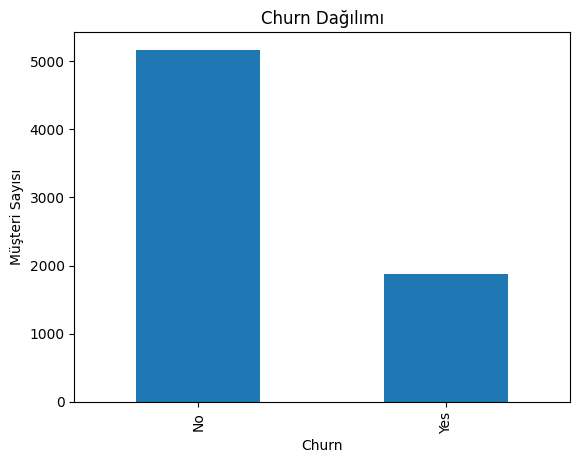

In [4]:
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Dağılımı')
plt.xlabel('Churn')
plt.ylabel('Müşteri Sayısı')
plt.show()

In [5]:
print(df.shape)
df.info()
df.describe()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


In [8]:
df = df.dropna(subset=['TotalCharges'])
print(df.shape)

(7032, 21)


In [9]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [10]:
df = df.drop('customerID', axis=1)

In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [12]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df.shape)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
(7032, 31)


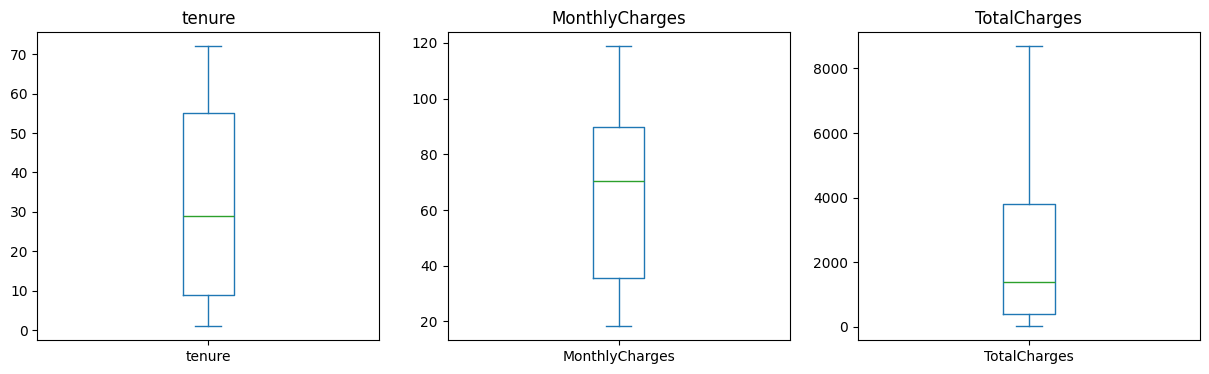

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['tenure'].plot(kind='box', ax=axes[0], title='tenure')
df['MonthlyCharges'].plot(kind='box', ax=axes[1], title='MonthlyCharges')
df['TotalCharges'].plot(kind='box', ax=axes[2], title='TotalCharges')
plt.show()

# tenure, MonthlyCharges ve TotalCharges için boxplot incelendi
# üç değişkende de belirgin bir aykırı değer görülmedi, bu yüzden
# satır silme veya sınırlandırma işlemi yapılmadı

In [14]:
df['charges_per_tenure'] = df['TotalCharges'] / (df['tenure'] + 1)

service_yes_cols = [col for col in df.columns if col.endswith('_Yes') and 
                     any(s in col for s in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                                              'TechSupport', 'StreamingTV', 'StreamingMovies'])]
df['total_services'] = df[service_yes_cols].sum(axis=1)

print(df[['charges_per_tenure', 'total_services']].describe())

       charges_per_tenure  total_services
count         7032.000000     7032.000000
mean            59.083067        2.038111
std             30.514438        1.847161
min              9.183333        0.000000
25%             26.225944        0.000000
50%             61.070387        2.000000
75%             84.877538        3.000000
max            118.969863        6.000000


In [15]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_tenure']
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges,charges_per_tenure
count,7.032000e+03,7.032000e+03,7.032000e+03,7.032000e+03
mean,-1.126643e-16,6.062651e-17,-1.119064e-16,-2.778715e-17
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.280248e+00,-1.547283e+00,-9.990692e-01,-1.635399e+00
25%,-9.542963e-01,-9.709769e-01,-8.302488e-01,-1.076850e+00
50%,-1.394171e-01,1.845440e-01,-3.908151e-01,6.513185e-02
75%,9.199259e-01,8.331482e-01,6.668271e-01,8.453803e-01
max,1.612573e+00,1.793381e+00,2.824261e+00,1.962712e+00


In [16]:
correlations = df.corr()['Churn'].sort_values(ascending=False)
print(correlations)

# en güçlü pozitif korelasyon: Fiber optic internet, Electronic check ödeme yöntemi
# en güçlü negatif korelasyon: tenure (uzun süreli müşteriler daha az ayrılıyor),
# iki yıllık kontrat, online security hizmeti alanlar
# bu sonuçlara göre öznitelik seçimini korelasyon büyüklüğüne göre yapıyorum

Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling_Yes                     0.191454
SeniorCitizen                            0.150541
charges_per_tenure                       0.070992
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService_Yes                         0.011691
gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
total_services                          -0.087882
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner_Yes                             -0.149982
Dependents_Yes                          -0.163128


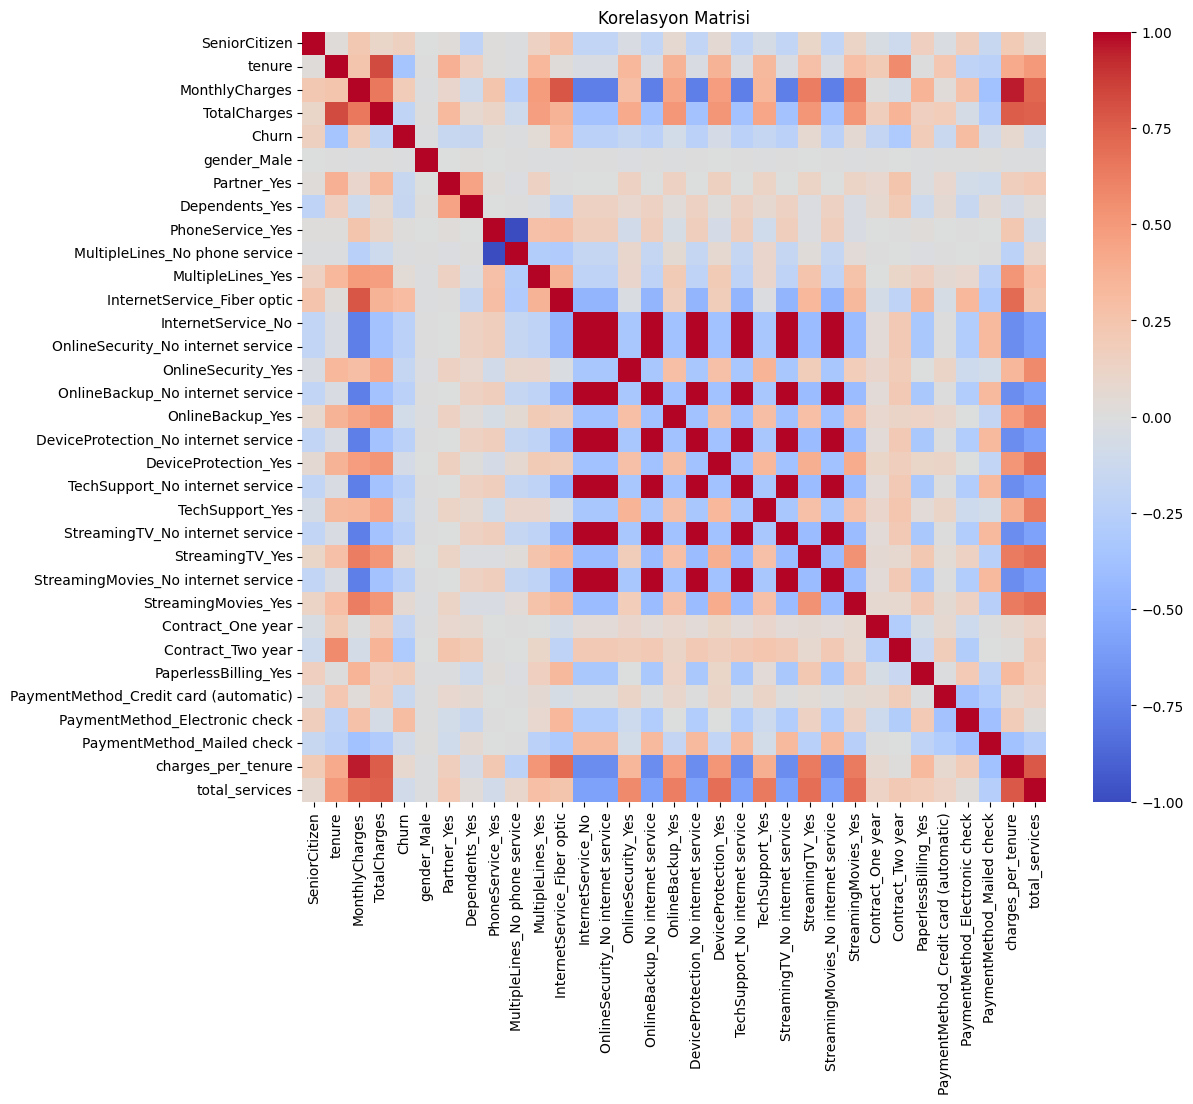

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Korelasyon Matrisi')
plt.show()

In [18]:
selected_features = correlations[abs(correlations) > 0.1].index.tolist()
selected_features.remove('Churn')
print(len(selected_features))
print(selected_features)

21
['InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'MonthlyCharges', 'PaperlessBilling_Yes', 'SeniorCitizen', 'PaymentMethod_Credit card (automatic)', 'Partner_Yes', 'Dependents_Yes', 'TechSupport_Yes', 'OnlineSecurity_Yes', 'Contract_One year', 'TotalCharges', 'OnlineSecurity_No internet service', 'StreamingMovies_No internet service', 'OnlineBackup_No internet service', 'InternetService_No', 'TechSupport_No internet service', 'DeviceProtection_No internet service', 'StreamingTV_No internet service', 'Contract_Two year', 'tenure']


In [19]:
from sklearn.model_selection import train_test_split

X = df[selected_features]
y = df['Churn']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(4500, 21) (1125, 21) (1407, 21)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, 'eğitildi')

Logistic Regression eğitildi
KNN eğitildi
Random Forest eğitildi


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

val_results = {}
for name, model in models.items():
    preds = model.predict(X_val)
    val_results[name] = {
        'accuracy': accuracy_score(y_val, preds),
        'precision': precision_score(y_val, preds),
        'recall': recall_score(y_val, preds),
        'f1': f1_score(y_val, preds)
    }

val_df = pd.DataFrame(val_results).T
print(val_df.round(4))

                     accuracy  precision  recall      f1
Logistic Regression    0.7938     0.6335  0.5318  0.5782
KNN                    0.7662     0.5709  0.4849  0.5244
Random Forest          0.7840     0.6346  0.4415  0.5207


In [22]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

grid.fit(X_train, y_train)

print('en iyi parametre:', grid.best_params_)
print('en iyi cv f1 skoru:', grid.best_score_)

en iyi parametre: {'C': 100}
en iyi cv f1 skoru: 0.5999665509876136


In [23]:
from sklearn.metrics import confusion_matrix, classification_report

final_model = grid.best_estimator_
test_preds = final_model.predict(X_test)

acc = accuracy_score(y_test, test_preds)
prec = precision_score(y_test, test_preds)
rec = recall_score(y_test, test_preds)
f1 = f1_score(y_test, test_preds)

print('accuracy:', acc)
print('precision:', prec)
print('recall:', rec)
print('f1:', f1)

print()
print('confusion matrix:')
print(confusion_matrix(y_test, test_preds))

print()
print(classification_report(y_test, test_preds))

accuracy: 0.8038379530916845
precision: 0.6484848484848484
recall: 0.5721925133689839
f1: 0.6079545454545454

confusion matrix:
[[917 116]
 [160 214]]

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [24]:
coef_series = pd.Series(final_model.coef_[0], index=selected_features).sort_values(key=abs, ascending=False)
print(coef_series.head(10))

Contract_Two year                -1.369329
tenure                           -1.296365
Contract_One year                -0.851515
TotalCharges                      0.655144
InternetService_Fiber optic       0.525297
OnlineSecurity_Yes               -0.522482
TechSupport_Yes                  -0.435589
SeniorCitizen                     0.337053
PaperlessBilling_Yes              0.294598
PaymentMethod_Electronic check    0.280963
dtype: float64


In [25]:
# model karşılaştırması: üç model arasında Logistic Regression validation setinde 
# en yüksek F1 skorunu verdi, GridSearchCV ile C=100 parametresi seçilerek test 
# setinde %80.4 accuracy ve %60.8 F1-score elde edildi

# en etkili değişkenler: iki yıllık sözleşme ve uzun tenure churn olasılığını düşürüyor,
# Fiber optic internet servisi ve Electronic check ödeme yöntemi ise churn olasılığını 
# artırıyor - bu, fiber müşterilerinin fiyat/hizmet memnuniyetsizliği yaşadığını 
# düşündürüyor

# model sınırlılıkları: Churn sınıfı dengesiz (%73 No, %27 Yes), bu recall'un 
# görece düşük kalmasına (0.57) neden oldu - yani model gerçek churn eden 
# müşterilerin bir kısmını kaçırıyor. Ayrıca ölçekleme tüm veri üzerinde fit 
# edildiği için hafif bir veri sızıntısı riski var, ileri seviye bir çalışmada 
# train/test ayrımından sonra ölçekleme yapılması daha doğru olurdu